In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [29]:
df = pd.read_csv('titanic_toy.csv')

In [30]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [31]:
df.isnull().mean()*100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

In [32]:
x = df.drop(columns=['Survived'])
y = df['Survived']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [33]:
mean_age = df['Age'].mean()
median_age = df['Age'].median()

mean_fare = df['Fare'].mean()
median_fare = df['Fare'].median()

In [34]:
x_train['mean_age'] = x_train['Age'].fillna(mean_age)
x_train['median_age'] = x_train['Age'].fillna(median_age)

x_train['mean_fare'] = x_train['Fare'].fillna(mean_fare)
x_train['median_fare'] = x_train['Fare'].fillna(median_fare)

In [35]:
x_train.sample(5)

,Age,Fare,Family,mean_age,median_age,mean_fare,median_fare
681,27.0,76.7292,0,27.0,27.0,76.729200,76.7292
487,58.0,29.7000,0,58.0,58.0,29.700000,29.7000
98,34.0,NaN,1,34.0,34.0,32.279338,14.4542
349,42.0,8.6625,0,42.0,42.0,8.662500,8.6625
876,20.0,9.8458,0,20.0,20.0,9.845800,9.8458


In [36]:
print("original Age Column Variance", x_train['Age'].var())
print("Age Column Variance After Mean Imputation", x_train['mean_age'].var())
print("Age Column Variance After Median Imputation", x_train['median_age'].var())

print("original Fare Column Variance", x_train['Fare'].var())
print("Fare Column Variance After Mean Imputation", x_train['mean_fare'].var())
print("Fare Column Variance After Median Imputation", x_train['median_fare'].var())

original Age Column Variance 204.3495133904614
Age Column Variance After Mean Imputation 161.813866455868
Age Column Variance After Median Imputation 162.33852985330878
original Fare Column Variance 2448.197913706318
Fare Column Variance After Mean Imputation 2324.2440261087
Fare Column Variance After Median Imputation 2340.098181126126


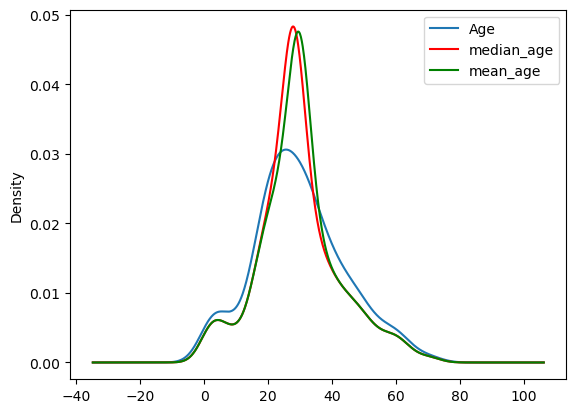

In [37]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
x_train['Age'].plot(kind='kde', ax=ax)

# variable imputed with the median
x_train['median_age'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
x_train['mean_age'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

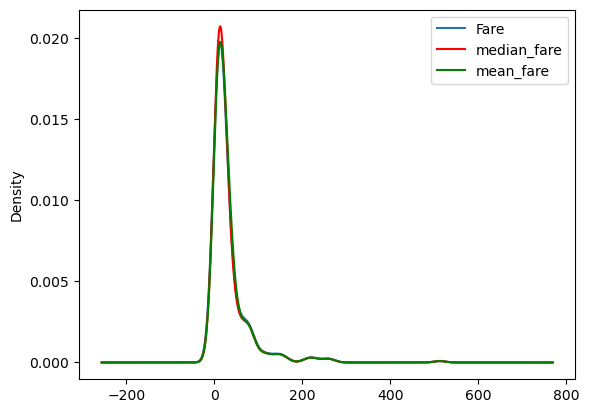

In [38]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
x_train['Fare'].plot(kind='kde', ax=ax)

# variable imputed with the median
x_train['median_fare'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
x_train['mean_fare'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

In [39]:
x_train.cov()

,Age,Fare,Family,mean_age,median_age,mean_fare,median_fare
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,66.631558,64.858451
Fare,70.719262,2448.197914,17.258917,55.800924,59.661820,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-5.143296,-5.088278,16.386748,16.476326
mean_age,204.349513,55.800924,-5.143296,161.813866,161.838181,52.948856,51.541608
median_age,204.349513,59.661820,-5.088278,161.838181,162.338530,56.613065,55.142638
mean_fare,66.631558,2448.197914,16.386748,52.948856,56.613065,2324.244026,2324.533881
median_fare,64.858451,2448.197914,16.476326,51.541608,55.142638,2324.533881,2340.098181


In [40]:
x_train.corr()

,Age,Fare,Family,mean_age,median_age,mean_fare,median_fare
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,0.090109,0.087355
Fare,0.092644,1.000000,0.208268,0.088382,0.094361,1.000000,1.000000
Family,-0.299113,0.208268,1.000000,-0.244475,-0.241469,0.205520,0.205942
mean_age,1.000000,0.088382,-0.244475,1.000000,0.998533,0.086339,0.083759
median_age,1.000000,0.094361,-0.241469,0.998533,1.000000,0.092165,0.089466
mean_fare,0.090109,1.000000,0.205520,0.086339,0.092165,1.000000,0.996731
median_fare,0.087355,1.000000,0.205942,0.083759,0.089466,0.996731,1.000000


<Axes: >

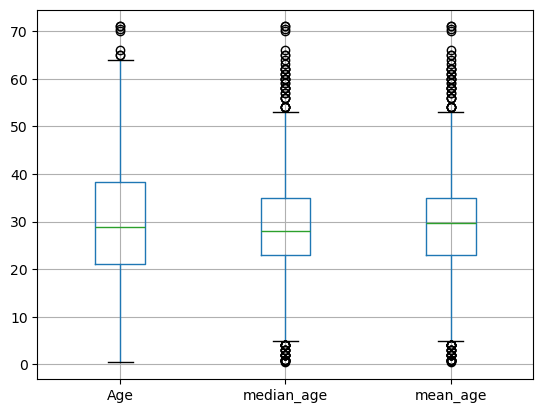

In [41]:
x_train[['Age', 'median_age', 'mean_age']].boxplot()

<Axes: >

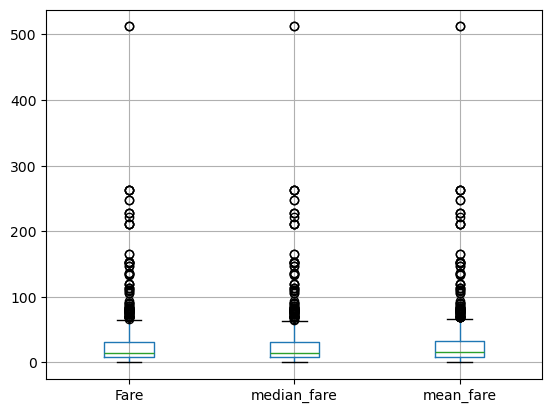

In [42]:
x_train[['Fare', 'median_fare', 'mean_fare']].boxplot()

In [43]:
# using Scikit Learn

In [44]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [45]:
imputer1 = SimpleImputer(strategy='mean')
imputer2 = SimpleImputer(strategy='median')

In [56]:
trf = ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])
],remainder='passthrough')

In [58]:
trf.fit(x_train)
x_train = trf.transform(x_train)
x_test = trf.transform(x_test)

x_train

array([[ 40.        ,  27.7208    ,   0.        ],
       [  4.        ,  16.7       ,   2.        ],
       [ 47.        ,   9.        ,   0.        ],
       ...,
       [ 71.        ,  49.5042    ,   0.        ],
       [ 29.78590426, 221.7792    ,   0.        ],
       [ 29.78590426,  25.925     ,   0.        ]])

In [59]:
trf.named_transformers_['imputer1'].statistics_

array([29.78590426])

In [60]:
trf.named_transformers_['imputer2'].statistics_

array([14.4583])